# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [223]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [224]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [225]:
# mostrar las primeras 5 filas de plans
plans. head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [226]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [227]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [228]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [229]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [230]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [231]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [232]:
# cantidad de nulos para users
print(users.isna().sum())
print("")
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [233]:
# cantidad de nulos para usage
print(usage.isna().sum())
print("")
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  Para el dataset de USERS la columna "city" y "churn_date" cuentan con valores nulos representando un 11% y 88% del valor total de filas.

  Para el dataset de USAGE la columna "date", "duration", "length" son las que cuentan con valores nulos las cuales represetan un 0.12%, 55% y 44% del valor total de filas.
    
- Indica qué harías: ¿imputar, eliminar, ignorar?

    Para el caso del dataset de USERS en la columna "city" se tendría que investigar mas la razón de los valores nulos para saber si se tienen que eliminar o dejarlos, para la columna "churn_date" debido a que es mayor al 80% se podría descartar del analisis pudiendo eliminarla.
  
    Para el caso del dataset de USAGE en la columna "date" como es menor al 5% se imputaria, para las columnas "duration" y "length" debido a que son columnas numericas y representan los valores nulos entre el 44% y 55% se tendra que investigar mas para saber si es conveniente imputar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [234]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` se puede observar que es una columna inestable ya que el promedio de la columna en comparación con su desviación estandar estan alejados, sin embargo es importante tener en cuenta que es una columna que representa clientes por lo cual es lógico su comportamiento.
- La columna `age` se puede identifar que su desviación estandar es relativamente alta, la cual está siendo afectada por un sentinel valor que aparece -999 como minimo.

In [235]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` considerando que son columnas que funcionan de primary keys se muestran estabables. Esto considerando que cada fila representa un cliente e incrementar con el tiempo.
- La columna `duration` y `length` se puede ver que son columnas estables ya que el promedio estan muy cerca de la desviación estandar, los valores minimos son los valores nulos los cuales se podrian reemplazar por el promedio o la media.

In [236]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print (users[columnas_user].describe())
print (" ")
print (users[columnas_user].value_counts())
print (" ")
print (users[columnas_user].value_counts(normalize=True))

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595
 
city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64
 
city      plan   
Bogotá    Basico     0.147833
CDMX      Basico     0.134240
Medellín  Basico     0.112716
GDL       Basico     0.084395
Bogotá    Premium    0.080997
MTY       Basico     0.077882
Cali      Basico     0.074200
CDMX      Premium    0.072501
Medellín  Premium    0.061739
Cali      Premium    0.045879
GDL       Premium    0.043047
MTY       Premium    0.037383
?         Basico     0.018408
          Premium    0.008779
dtype: float64


- La columna `city` se puede observar que cuenta con 7 categorías unicas de las cuales Bogota representa la ciudad numero 1 con 808 registros. Tambien se puede ver que el 30% de los registros se encuentran en ciudades como Bogota, CDMX y Medellín con el plan basico contratado. Solo 65 registros aparecen como nulos en esta columna. Existe un sentinel en esta columna ["?"]
- La columna `plan` se puede observar que solo hay dos categorias "Basico" y "Premium", de las cuales el plan basico es el plan mas contratado siendo las ciudades de Bogota, Medellín y CDMX las top 3 del dataset.

In [237]:
# explorar columna categórica de usage
usage['type']
print (usage['type'].describe())
print (" ")
print (usage['type'].value_counts())
print (" ")
print (usage['type'].value_counts(normalize=True))

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
 
text    22092
call    17908
Name: type, dtype: int64
 
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` se puede observar que la categoria mas frecuente son los mensajes de texto representado el 55% del total de los registros, sin embargo tambien es significativo el 44% de las llamadas que realizan los usuarios. No se identificaron valores nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
      Para la columna `city` se encontraron 65 valores nulos los cuales representan el 1.84% del total de los datos.
      Para la columna `age` se encontraron sentinels los cuales estan generando que la columna se vuelva inestable aumentando         su desviación estandar.
- ¿Qué acción tomarías?
      Para la columna `city` se dejarán como nulos debido a que no es representativa la muestra.
      Para la columna `age` se reemplazarán con el promedio o la media para no afectar la desviación estandar de los datos.   

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [238]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = "coerce").dt.year

In [239]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = "coerce").dt.year

In [240]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, se puede ver que existe el año 2026, para este analisis solo se trabaja como maximo con fechas de 2024.

In [241]:
# Revisar los años presentes en `date` de usage
usage['date'].unique()

array([2024.,   nan])

En `date`, se puede ver que existen años nulos

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) 
- ¿Qué harías con ellas?

    Para la columna de `reg_date` años despues de 2024, los que se deberan descargar del dataset para poder continuar con el analisis.
    Para la columna `date` se encuentran fechas/años nulos los cuales representan el 1% equivalente a 50 registros por lo cual se podrian dejar como nulos en el analisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [242]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [243]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [244]:
# Marcar fechas futuras como NA para reg_date
def reemplazar_sentinels_global(df,text_cols):
    text_sentinels = [2026]
    for col in text_cols:
        users['reg_date'] = users['reg_date'].replace(text_sentinels, "NA")
    return df

# Verificar cambios
columnas_texto = users['reg_date']      # columnas texto a procesar

# aplicar función
reemplazar_sentinels_global(users['reg_date'], columnas_texto)

users['reg_date'].unique()

array([2022, 'NA', 2023, 2024], dtype=object)

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [245]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending = False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [246]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending = False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`:

- Para el caso de `duration` se puede observa que el 99 % de los registros que aparecen nulos se encuentran en la categoria `text` lo cual hace sentido ya que esta columna se tiene para llevar el registro de la duración de las llamadas.
- Para el caso de `length` se puede observar lo contrario para las llamadas es donde aparece el 99% de los nulos lo cual nos deja ver que esta columna es para llevar el registro de la longitud del tamaño del mensaje.

En conclusión los valores nulos se pueden dejar como tal concluyendo que son valores faltantes **MAR**, dependiendo su ausencia de la variable `type`.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [247]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum','is_call': 'sum','duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [248]:
# Renombrar columnas
usage_agg = usage_agg.rename( columns = {"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [249]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'])
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [250]:
# Resumen estadístico de las columnas numéricas
user_profile_2024 = user_profile[user_profile['reg_date'] == 2024]
user_profile_2024.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000
mean,13332.699248,48.414286,5.500000,4.557143,24.126669
std,384.969999,17.963443,2.382293,2.140329,19.458620
min,12666.000000,18.000000,0.000000,0.000000,0.000000
25%,12999.250000,33.000000,4.000000,3.000000,11.332500
50%,13333.500000,48.000000,5.000000,4.000000,20.325000
75%,13665.750000,64.000000,7.000000,6.000000,32.542500
max,13999.000000,79.000000,16.000000,13.000000,155.690000


In [251]:
# Distribución porcentual del tipo de plan
cat_cols = ['plan']
print (user_profile_2024[cat_cols].value_counts(normalize=True))

plan   
Basico     0.656391
Premium    0.343609
dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

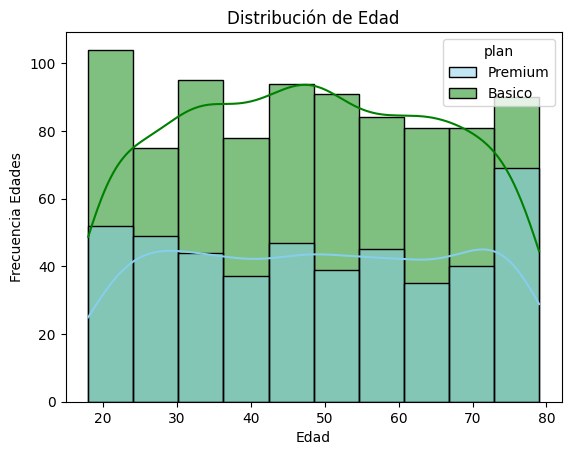

In [252]:

# Histograma para visualizar la edad (age)
sns.histplot(user_profile_2024, x= 'age', hue='plan', bins=10, kde=True, palette=['skyblue','green'])


plt.xlabel('Edad')
plt.ylabel('Frecuencia Edades')
plt.title('Distribución de Edad')

plt.show()

💡Insights: Las curvas muestran un comportamiendo disperso, mostrando picos en los rangos de edades de +20 y +70 años. Mostrando mayor frecuencia de edades para el plan premium en rango de edades de +70 años. En general la distribución de planes en cada rango de edades es 50 - 50.
- Distribución casi uniforme, excepto por un pico entre 45 y 55 años de edad para el básico, para el plan premium se mantiene aun mas uniforme a lo largo de los rangos de edades.

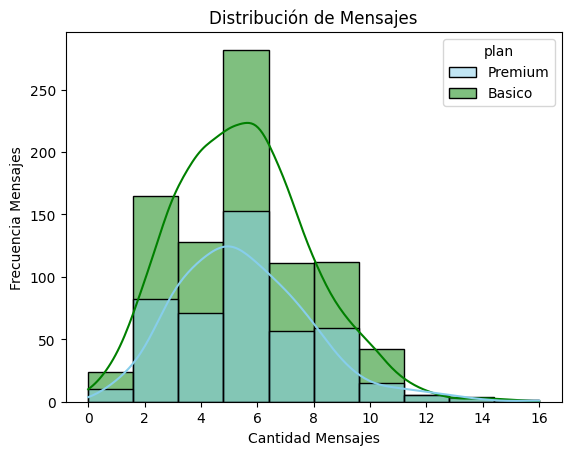

In [253]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile_2024, x= 'cant_mensajes', hue='plan', bins=10, kde=True, palette=['skyblue','green'])

plt.xlabel('Cantidad Mensajes')
plt.ylabel('Frecuencia Mensajes')
plt.title('Distribución de Mensajes')

plt.show()

💡Insights: La mayoria de los cliente mandó entre 5 - 6 mensajes durante 2024.
- Distribución levemente sesgada a la derecha por lo que la media no representa la cantidad de mensajes tipica. Se muestran outliers que estan en el rango de entre 12 y 1

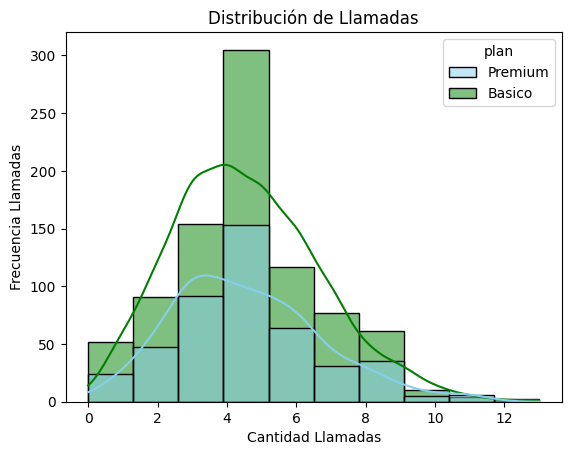

In [254]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile_2024, x= 'cant_llamadas', hue='plan', bins=10, kde=True, palette=['skyblue','green'])

plt.xlabel('Cantidad Llamadas')
plt.ylabel('Frecuencia Llamadas')
plt.title('Distribución de Llamadas')

plt.show()

💡Insights: La mayoria de los clientes tanto con planes básicos como premium hace entre 4 y 5 llamadas en un año. 
- Distribución levemente sesgada a la derecha por lo que la media no representa la cantidad de mensajes tipica. Se observan outliers en un rango que va entre 10 y 12 llamadas.

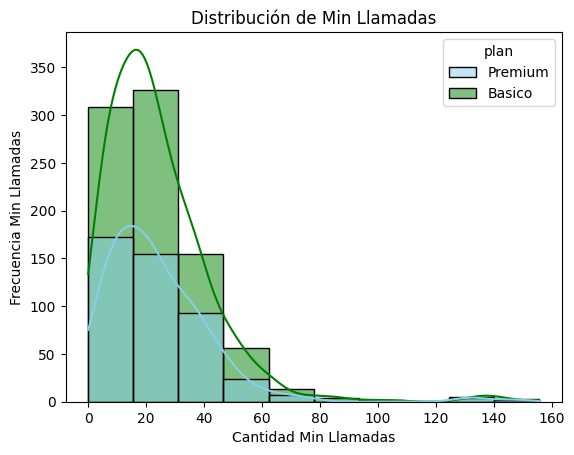

In [255]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile_2024, x= 'cant_minutos_llamada', hue='plan', bins=10, kde=True, palette=['skyblue','green'])

plt.xlabel('Cantidad Min Llamadas')
plt.ylabel('Frecuencia Min Llamadas')
plt.title('Distribución de Min Llamadas')

plt.show()

💡Insights: La mayoria de los clientes hacen llamadas en un rango de 0 a 40 minutos.
- Distribución sesgada a la derecha mostrando outliers que van del rango de los 80 a los 160 minutos, por lo que el promedio no representa la cantidad tipica de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

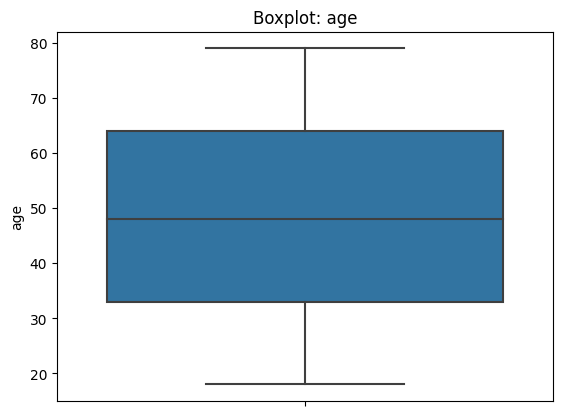

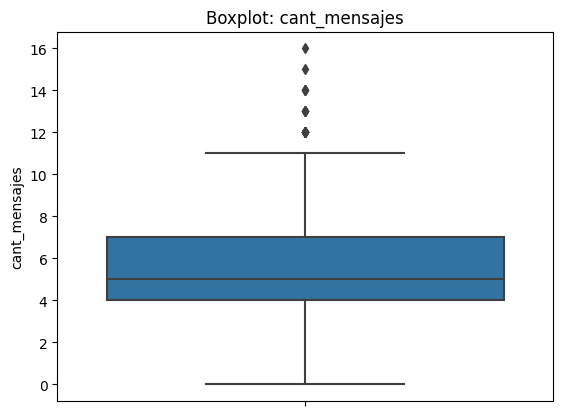

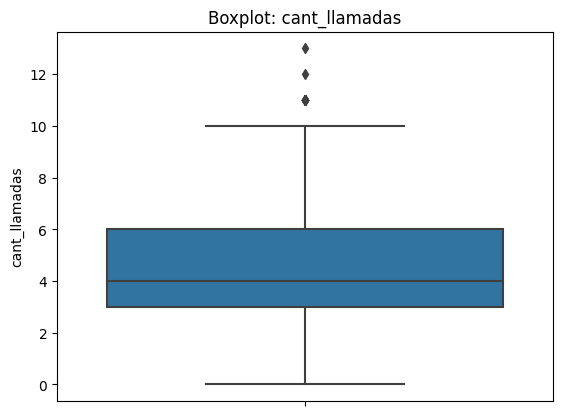

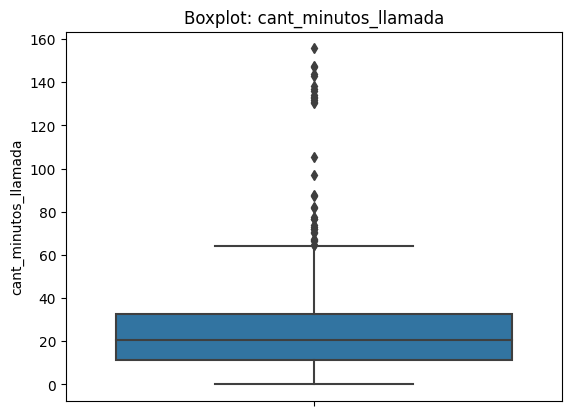

In [256]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    sns.boxplot(data= user_profile_2024, y= col)
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: no presenta outliers.
- cant_mensajes: presenta outliers que se encuentran en un rango de 11 a 16 mensajes.
- cant_llamadas: presenta outliers que se encuentran en un rango de 10 a 12 llamadas.
- cant_minutos_llamada: presenta outliers que se encuentran en un rango de 60 a 160 minutos por llamada.

In [257]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile_2024[col].quantile(0.25)
    Q3 = user_profile_2024[col].quantile(0.75)
    IQR = Q3 - Q1
    Upper = Q3 + 1.5 * IQR
    print(f'Limite_Superior {col} :', Upper)


Limite_Superior cant_mensajes : 11.5
Limite_Superior cant_llamadas : 10.5
Limite_Superior cant_minutos_llamada : 64.35749999999999


In [258]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile_2024[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,1330.000000,1330.000000,1330.000000
mean,5.500000,4.557143,24.126669
std,2.382293,2.140329,19.458620
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.332500
50%,5.000000,4.000000,20.325000
75%,7.000000,6.000000,32.542500
max,16.000000,13.000000,155.690000


💡Insights: 
- cant_mensajes: Se mantienen los outliers, ya que al observar la diferencia entre el valor maximo y el limite superior (16 - 11.5 = 4.5) es creible y no tan alejado de la realidad.
- cant_llamadas: Se mantienen los outliers, ya que al observar la diferencia entre el valor maximo y el limite superior (13 - 10.5 = 2.5) es creible y no tan alejado de la realidad.
- cant_minutos_llamada: Se mantienen los outliers, ya que a pesar de la marcada diferencia entre el valor maximo y el limite superior (155.69 - 64.35 = 91.3) una llamada de hasta dos horas puede ser real.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [259]:
# Crear columna grupo_uso
def classify_segment(row):
    mensajes = row['cant_mensajes']
    llamadas = row['cant_llamadas']
    
    # Manejo de valores nulos/faltantes
    if pd.isna(mensajes) or pd.isna(llamadas):
        return "Error en Datos"
        
    # Segmentación
    if llamadas <= 5 and mensajes <= 5:
        return "Bajo Uso"
    elif llamadas <= 10 and mensajes <= 10:
        return "Uso Medio"
    else:
        return "Alto Uso"

user_profile_2024['grupo_uso'] = user_profile_2024.apply(classify_segment, axis =1)

/tmp/ipykernel_32/1313340317.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_profile_2024['grupo_uso'] = user_profile_2024.apply(classify_segment, axis =1)


In [260]:
# verificar cambios
user_profile_2024.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
2665,12666,Mateo,Garcia,20.0,Cali,2024,Premium,NaN,13,3,11.50,Alto Uso
2666,12667,Carlos,Gomez,72.0,Cali,2024,Premium,NaN,3,7,33.27,Uso Medio
2667,12668,Ana,Torres,21.0,CDMX,2024,Basico,NaN,5,7,87.56,Uso Medio
2668,12669,Sofia,Garcia,58.0,CDMX,2024,Basico,NaN,4,5,27.62,Bajo Uso
2669,12670,Ana,Garcia,54.0,MTY,2024,Premium,NaN,9,4,31.90,Uso Medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [261]:
# Crear columna grupo_edad
def classify_segment(row):
    edad = row['age']
    
    # Manejo de valores nulos/faltantes
    if pd.isna(edad):
        return "Error en Datos"
        
    # Segmentación
    if edad <= 30:
        return "Joven"
    elif edad <= 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile_2024['grupo_edad'] = user_profile_2024.apply(classify_segment, axis =1)

/tmp/ipykernel_32/1281811228.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_profile_2024['grupo_edad'] = user_profile_2024.apply(classify_segment, axis =1)


In [262]:
# verificar cambios
user_profile_2024.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
2665,12666,Mateo,Garcia,20.0,Cali,2024,Premium,NaN,13,3,11.50,Alto Uso,Joven
2666,12667,Carlos,Gomez,72.0,Cali,2024,Premium,NaN,3,7,33.27,Uso Medio,Adulto Mayor
2667,12668,Ana,Torres,21.0,CDMX,2024,Basico,NaN,5,7,87.56,Uso Medio,Joven
2668,12669,Sofia,Garcia,58.0,CDMX,2024,Basico,NaN,4,5,27.62,Bajo Uso,Adulto
2669,12670,Ana,Garcia,54.0,MTY,2024,Premium,NaN,9,4,31.90,Uso Medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

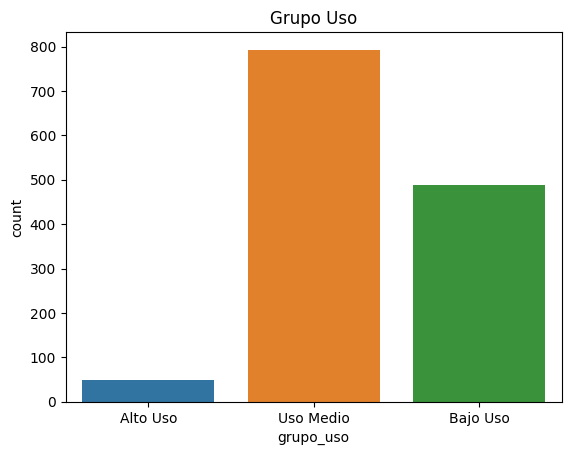

In [263]:
# Visualización de los segmentos por uso
sns.countplot(data = user_profile_2024, x='grupo_uso')
plt.title('Grupo Uso')
plt.show()

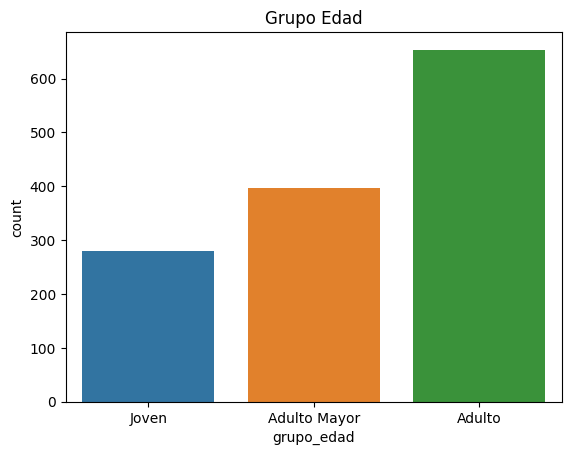

In [264]:
# Visualización de los segmentos por edad

sns.countplot(data = user_profile_2024, x='grupo_edad')
plt.title('Grupo Edad')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Para el dataset de USERS la columna `city` y `churn_date` contaban con valores nulos representando un 11% y 88% del valor total de filas.
- Para el dataset de USAGE la columna `date`, `duration`, `length` son las que contaban con valores nulos los cuales represetaban un 0.12%, 55% y 44% del valor total de filas.
- La columna `age` se puedo identificar que su desviación estandar era relativamente alta, la cual estaba siendo afectada por un sentinel (valor de -999) el cual fue sustituido por la mediana de la columna.
- La columna `city` se encontraron valores sentinels (valor de "?") los cuales representaban el 1.8% del valor total de la columna, por lo que se sustituyeron por "NA".
- Se ajustaron los rangos de las fechas de la columna `date` para que en el análisis solo se tomaran en cuenta datos hasta el año 2024.
- Las columnas `duration` y `lenght` se identificaron que el 55% de sus valores eran nulos, llegando a la conclusión de que estos valores dependian de la columna `type` por lo que no se dejaron como "NA".

🔍 **Segmentos por Edad**
- Primer lugar lo ocupan los `adultos` (>30 a <=60), el segundo lugar los `adultos mayores` (>60) y tercer lugar los `jovenes` (<=30).
- Se pudo observar que existe un leve pico entre los rangos de edad de 45 y 55 años, con una proporción del 65% para el plan `Basico` y 34% para el plan `Premium`.


📊 **Segmentos por Nivel de Uso**
- Primer lugar es `Uso medio` (llamadas <= 10 y mensajes <= 10), el segundo lugar es `Bajo Uso` (llamadas <= 5 y mensajes <= 5) y tercero `Alto Uso` (llamadas > 10 y mensajes > 10).
- La mayoria de los clientes manda entre 5 - 6 mensajes, con una proporción del 65% para el plan `Basico` y 34% para el plan `Premium`.
- La mayoria de los clientes hace entre 4 y 5 llamadas, con una proporción del 65% para el plan `Basico` y 34% para el plan `Premium`.
- La mayoria de los clientes hacen llamadas en un rango de 0 a 40 minutos, con una proporción del 65% para el plan `Basico` y 34% para el plan `Premium`.
- Existen outliers para las categorias de `cant_mensajes` presentando valores de 11 a 16 mensajes, `cant_llamadas` presentado valores de 10 a 12 llamadas y `cant_minutos_llamada` presentado valores 60 a 160 minutos por llamada en los cuales la proporción del tipo de plan tiende a invertirse siendo la de mayor el plan `Premium`.



➡️ Esto sugiere que ...

- Los adultos son tu mayor mercado seguido de los adultos mayores, de los cuales su uso es de nivel medio a nivel bajo considerando llamadas y mensajes. Existe un mercado de outliers que es de alto uso que puede ser un mercado joven ya que es gente mas social y con tiempo mas libre o de igual manera gente adulta mayor ya que tiende a marcar planes premuim en esos outliers.

💡 **Recomendaciones**
- Tu mayor mercado son `adultos` de los cuales el 65% cuentan con un plan basico y el 34% con un plan premium. Seria recomendable investigar la razon de porque es bajo su uso, si les gustaria contar con otro tipo de servicios.
- Tu segundo mayor mercado son los `adultos mayores` de los cuales el 65% cuentan con un plan basico y el 34% con un plan premium de los cuales su uso es moderado. Seria recomendable ofrecerles el plan premium y decirle los beneficios que pueden obtener con el ya que su uso es mayor.
- Para el tercer mercado que es el `joven` es recomendable investigar mayor a fondo que tipo de planes son los que contratan ya que su uso es mayor, con lo cual podrian se podria diseñar un plan especifico para ellos pudiendo ser una categoria intermedia entre premium y b[sico.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`